---
## 1. Imports & Global Settings <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats

warnings.filterwarnings('ignore')

# Global plot theme 
sns.set_theme(style="whitegrid", context="talk", palette="deep")

plt.rcParams.update({
    "figure.figsize":    (12, 6),
    "axes.titlesize":    18,
    "axes.titleweight": "bold",
    "axes.labelsize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Project colour palette
TEAL   = "#0096C7"
RED    = "#E63946"
AMBER  = "#F4A261"
GREEN  = "#2A9D8F"
NAVY   = "#1D3557"
MUTED  = "#6C757D"

RANDOM_STATE = 42
print("Imports and settings loaded.")

Imports and settings loaded.


---
## 2. Load & Inspect Data <a id='2'></a>

In [2]:
FILE_PATH = "MASTER_DATASET.csv"

df = pd.read_csv(FILE_PATH)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 89 rows × 56 columns


,Date,NGN_USD_Official,NGN_USD_Parallel,Inflation_Headline,Inflation_Food,Inflation_Core,CBN_MPR,M2_NGN_Trillions,FX_Reserves_B_USD,Remittances_B_USD,...,SC_Dominance_Growth,Real_FX_Depreciation,log_Brent,log_Remittances,log_FX_Reserves,log_M2,Inflation_FX_Interaction,Crisis_Intensity,Naira_Appreciation_Dummy,Real_Rate_Positive
0,2019-01-01,306.95,363,11.37,13.56,8.59,14.0,33.30,42.72,1.983,...,NaN,NaN,4.083284,0.684611,3.754667,3.505557,NaN,0,0,1
1,2019-02-01,306.95,362,11.31,13.47,8.52,14.0,33.74,44.67,1.938,...,6.329,-11.310,4.173618,0.661657,3.799302,3.518684,0.0000,0,0,1
2,2019-03-01,306.97,361,11.25,13.28,8.25,13.5,34.18,44.75,1.892,...,-8.333,-11.244,4.207376,0.637634,3.801091,3.531641,0.0731,0,0,1
3,2019-04-01,307.00,362,11.37,13.57,8.37,13.5,34.62,45.12,1.846,...,-15.584,-11.360,4.274859,0.613021,3.809326,3.544432,0.1114,0,0,1
4,2019-05-01,307.00,363,11.40,13.62,8.42,13.5,35.07,45.10,1.800,...,-23.077,-11.400,4.266616,0.587787,3.808882,3.557346,0.0000,0,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      89 non-null     object 
 1   NGN_USD_Official          89 non-null     float64
 2   NGN_USD_Parallel          89 non-null     int64  
 3   Inflation_Headline        89 non-null     float64
 4   Inflation_Food            89 non-null     float64
 5   Inflation_Core            89 non-null     float64
 6   CBN_MPR                   89 non-null     float64
 7   M2_NGN_Trillions          89 non-null     float64
 8   FX_Reserves_B_USD         89 non-null     float64
 9   Remittances_B_USD         89 non-null     float64
 10  Brent_Oil_USD             89 non-null     float64
 11  GDP_PerCapita_USD         89 non-null     float64
 12  USDT_MC_B_USD             89 non-null     float64
 13  USDC_MC_B_USD             89 non-null     float64
 14  Global_Crypt

In [4]:
df.describe().round(4)

,NGN_USD_Official,NGN_USD_Parallel,Inflation_Headline,Inflation_Food,Inflation_Core,CBN_MPR,M2_NGN_Trillions,FX_Reserves_B_USD,Remittances_B_USD,Brent_Oil_USD,...,SC_Dominance_Growth,Real_FX_Depreciation,log_Brent,log_Remittances,log_FX_Reserves,log_M2,Inflation_FX_Interaction,Crisis_Intensity,Naira_Appreciation_Dummy,Real_Rate_Positive
count,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,89.0000,...,88.0000,88.0000,89.0000,89.0000,89.0000,89.0000,88.0000,89.0000,89.0000,89.0000
mean,782.5154,871.6742,19.5753,22.1142,16.4260,18.0112,85.1074,38.5287,1.6914,73.6273,...,4.1611,-17.7117,4.2604,0.5233,3.6450,4.2796,49.0813,0.7528,0.0899,0.3820
std,516.8117,482.2061,7.0028,8.3670,6.2674,6.3568,50.1935,4.4492,0.1150,18.8757,...,19.3722,9.5190,0.2977,0.0686,0.1129,0.5701,219.4964,0.9803,0.2876,0.4886
min,306.9500,361.0000,11.0200,8.8900,8.0000,11.5000,33.3000,31.7700,1.4330,18.3800,...,-26.8790,-43.3220,2.9113,0.3598,3.4585,3.5056,-296.5691,0.0000,0.0000,0.0000
25%,395.0000,470.0000,14.4500,15.4800,10.9700,12.5000,43.5200,35.1000,1.6290,64.1600,...,-5.7155,-21.4060,4.1614,0.4880,3.5582,3.7732,0.0000,0.0000,0.0000,0.0000
50%,435.0000,701.0000,17.7100,21.0000,16.8000,15.5000,62.6300,37.9100,1.6710,73.6400,...,1.7440,-17.8135,4.2992,0.5134,3.6352,4.1372,4.3224,0.0000,0.0000,0.0000
75%,1432.0000,1450.0000,22.9700,24.6100,21.5200,26.5000,124.1000,41.5000,1.7870,84.3200,...,9.8035,-12.6042,4.4346,0.5805,3.7257,4.8211,24.2896,2.0000,0.0000,1.0000
max,1678.0000,1685.0000,34.8000,40.8700,28.7500,27.5000,185.0000,49.0000,1.9830,117.2500,...,78.9770,20.9330,4.7643,0.6846,3.8918,5.2204,1649.8265,3.0000,1.0000,1.0000


---
## 3. Missing Value Treatment <a id='3'></a>

In [5]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %":     missing_pct
}).query("`Missing Count` > 0")

print(f"Columns with missing values: {len(missing_report)}")
print(missing_report)

Columns with missing values: 10
                          Missing Count  Missing %
FX_Return_Official                    1       1.12
FX_Return_Parallel                    1       1.12
Inflation_Momentum                    1       1.12
FX_Volatility_3m                      3       3.37
FX_Volatility_6m                      6       6.74
SC_Nigeria_Growth                     1       1.12
USDT_MC_Growth                        1       1.12
SC_Dominance_Growth                   1       1.12
Real_FX_Depreciation                  1       1.12
Inflation_FX_Interaction              1       1.12


In [6]:
cols_with_missing = [
    "FX_Return_Official",
    "FX_Return_Parallel",
    "Inflation_Momentum",
    "FX_Volatility_3m",
    "FX_Volatility_6m",
    "SC_Nigeria_Growth",
    "USDT_MC_Growth",
    "SC_Dominance_Growth",
    "Real_FX_Depreciation",
    "Inflation_FX_Interaction",
]

# Filter to only those that actually exist and have nulls
cols_to_impute = [c for c in cols_with_missing if c in df.columns and df[c].isna().any()]

# Per-column mean imputation
df[cols_to_impute] = df[cols_to_impute].fillna(df[cols_to_impute].mean())

print(f"Imputed {len(cols_to_impute)} column(s): {cols_to_impute}")
print(f"Remaining missing values: {df.isna().sum().sum()}")

Imputed 10 column(s): ['FX_Return_Official', 'FX_Return_Parallel', 'Inflation_Momentum', 'FX_Volatility_3m', 'FX_Volatility_6m', 'SC_Nigeria_Growth', 'USDT_MC_Growth', 'SC_Dominance_Growth', 'Real_FX_Depreciation', 'Inflation_FX_Interaction']
Remaining missing values: 0


---
## 4. Exploratory Data Analysis <a id='4'></a>

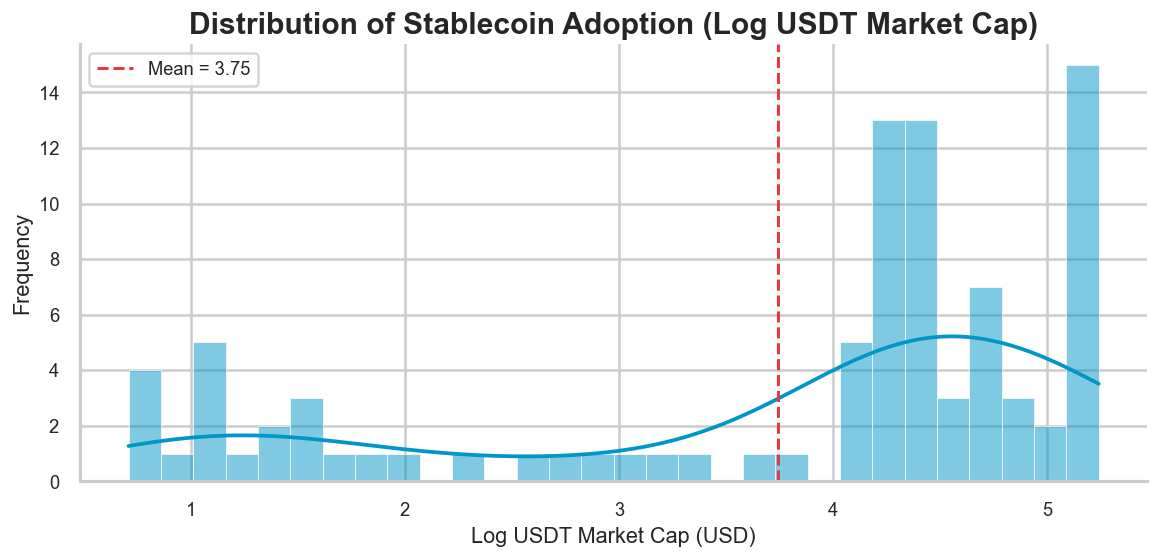

In [7]:
# ── FIX: added proper axis labels, subtitle, and annotation ───────
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df["log_USDT_MC"],
    kde=True,
    bins=30,
    color=TEAL,
    edgecolor="white",
    linewidth=0.4,
    ax=ax,
)

ax.set_title("Distribution of Stablecoin Adoption (Log USDT Market Cap)")
ax.set_xlabel("Log USDT Market Cap (USD)")
ax.set_ylabel("Frequency")

# Annotate mean
mean_val = df["log_USDT_MC"].mean()
ax.axvline(mean_val, color=RED, linestyle="--", linewidth=1.8, label=f"Mean = {mean_val:.2f}")
ax.legend()

plt.tight_layout()
plt.show()

---
## 5. Outlier Detection <a id='5'></a>

Outliers here reflect real economic shocks (2023 Naira float, 2024 FX crisis) — **not** data errors. We keep them but document them clearly.

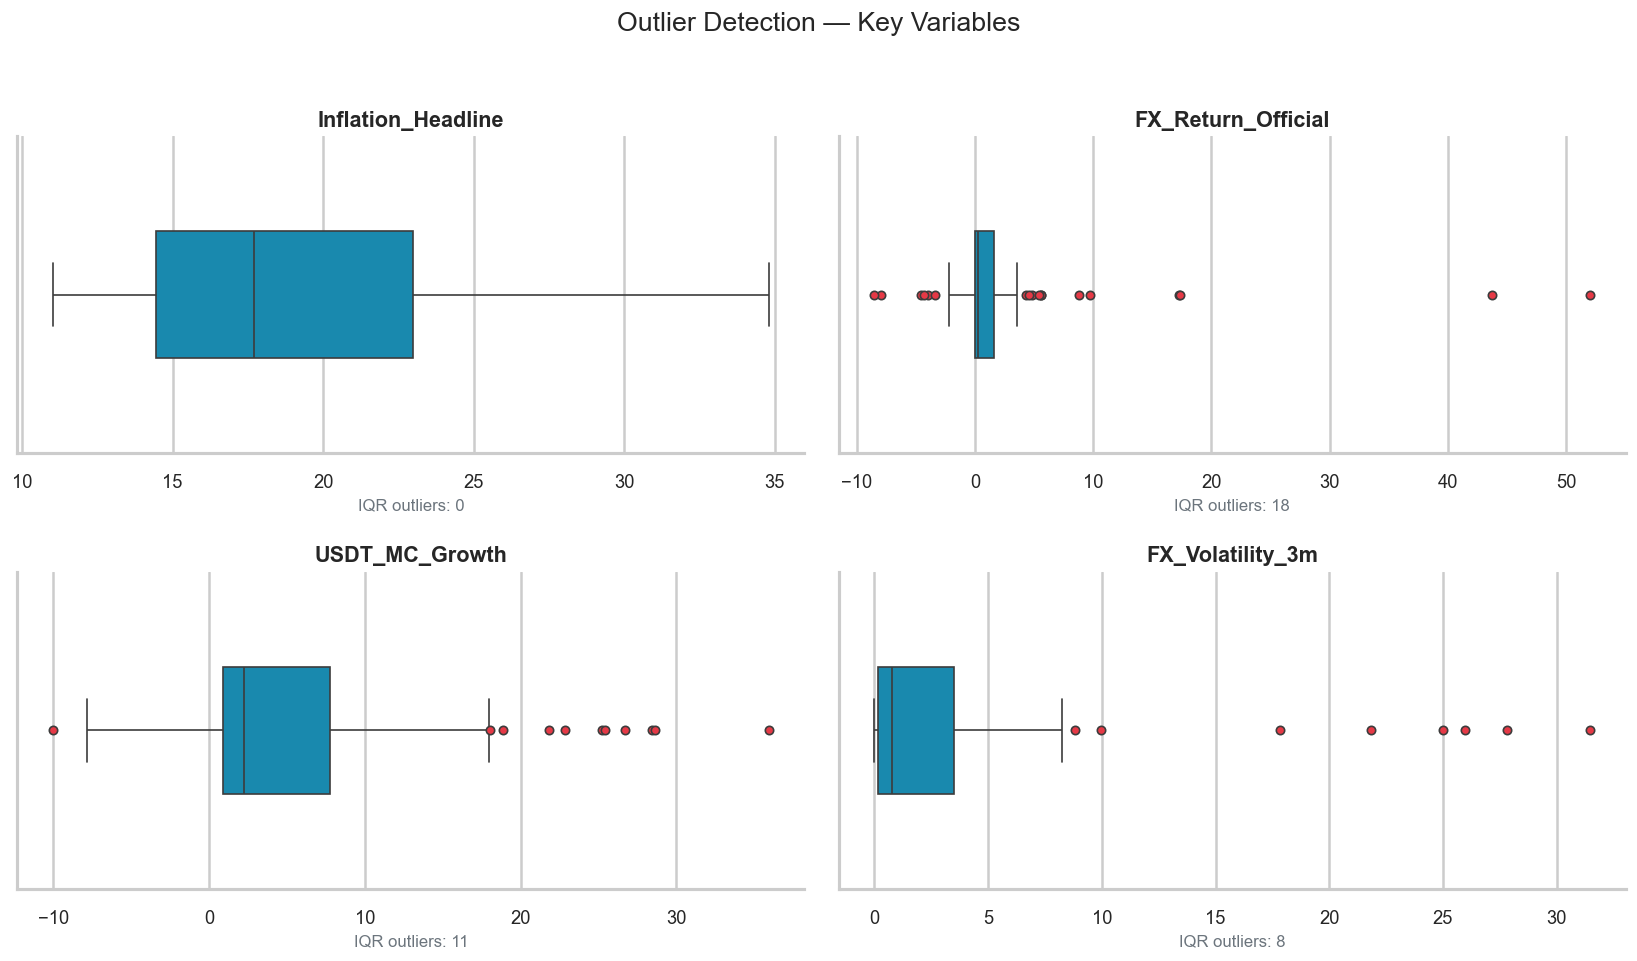

In [8]:
# ── FIX: fixed subplot aspect ratio (was 16×18 which distorts boxes)
# Added IQR-based outlier counts as annotations

outlier_cols = [
    "Inflation_Headline",
    "FX_Return_Official",
    "USDT_MC_Growth",
    "FX_Volatility_3m",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df[col], ax=axes[i], color=TEAL, width=0.4, flierprops=dict(marker="o", markerfacecolor=RED, markersize=5))
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel("")

    # Annotate with IQR outlier count
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    axes[i].set_xlabel(f"IQR outliers: {n_outliers}", fontsize=10, color=MUTED)

fig.suptitle("Outlier Detection — Key Variables", fontsize=16, y=1.01)
plt.tight_layout()
sns.despine()
plt.show()

---
## 6. Skewness & Transformations <a id='6'></a>

In [9]:
# Check skewness before any transformation
skew_before = df.skew(numeric_only=True).sort_values(key=abs, ascending=False)
print("Top skewed columns (|skew| > 1):")
print(skew_before[skew_before.abs() > 1].round(3))

Top skewed columns (|skew| > 1):
Inflation_Momentum         -5.586
Inflation_FX_Interaction    5.525
D_Iran_Oil_Crisis           5.256
FX_Return_Official          4.777
FX_Return_Parallel          4.513
FX_Volatility_3m            3.003
Naira_Appreciation_Dummy    2.917
SC_Dominance_Growth         1.851
FX_Volatility_6m            1.799
D_CPI_Rebase_2025           1.599
log_Brent                  -1.505
USDT_MC_Growth              1.495
log_SC_Nigeria             -1.250
D_COVID                     1.192
FX_Spread_Pct               1.164
Real_FX_Depreciation        1.038
log_SC_Total_MC            -1.036
dtype: float64


In [10]:
positive_skewed = ["FX_Volatility_3m", "FX_Volatility_6m"]

for col in positive_skewed:
    assert df[col].min() >= 0, f"{col} has negative values — log1p not appropriate"
    df[f"log1p_{col}"] = np.log1p(df[col])


yeo_cols = [
    "FX_Return_Official",
    "FX_Return_Parallel",
    "USDT_MC_Growth",
    "SC_Dominance_Growth",
    "FX_Spread_Pct",
    "Real_FX_Depreciation",
    "Inflation_FX_Interaction",
    "Inflation_Momentum",
]

pt = PowerTransformer(method="yeo-johnson")
df[yeo_cols] = pt.fit_transform(df[yeo_cols])

print("Yeo-Johnson transformation applied to:", yeo_cols)

Yeo-Johnson transformation applied to: ['FX_Return_Official', 'FX_Return_Parallel', 'USDT_MC_Growth', 'SC_Dominance_Growth', 'FX_Spread_Pct', 'Real_FX_Depreciation', 'Inflation_FX_Interaction', 'Inflation_Momentum']


In [11]:
log_cols_new = [f"log1p_{c}" for c in positive_skewed]
all_transformed = positive_skewed + log_cols_new + yeo_cols

skew_after = df[all_transformed].skew().round(3)
skew_table = pd.DataFrame({"Skewness After Transform": skew_after})
print(skew_table.to_string())
print("\n All transformed skewness values should be close to 0.")

                          Skewness After Transform
FX_Volatility_3m                             3.003
FX_Volatility_6m                             1.799
log1p_FX_Volatility_3m                       0.940
log1p_FX_Volatility_6m                       0.465
FX_Return_Official                          -0.295
FX_Return_Parallel                           0.486
USDT_MC_Growth                               0.071
SC_Dominance_Growth                          0.254
FX_Spread_Pct                               -0.120
Real_FX_Depreciation                        -0.613
Inflation_FX_Interaction                     0.637
Inflation_Momentum                           0.268

 All transformed skewness values should be close to 0.


---
## 7. Correlation Analysis <a id='7'></a>

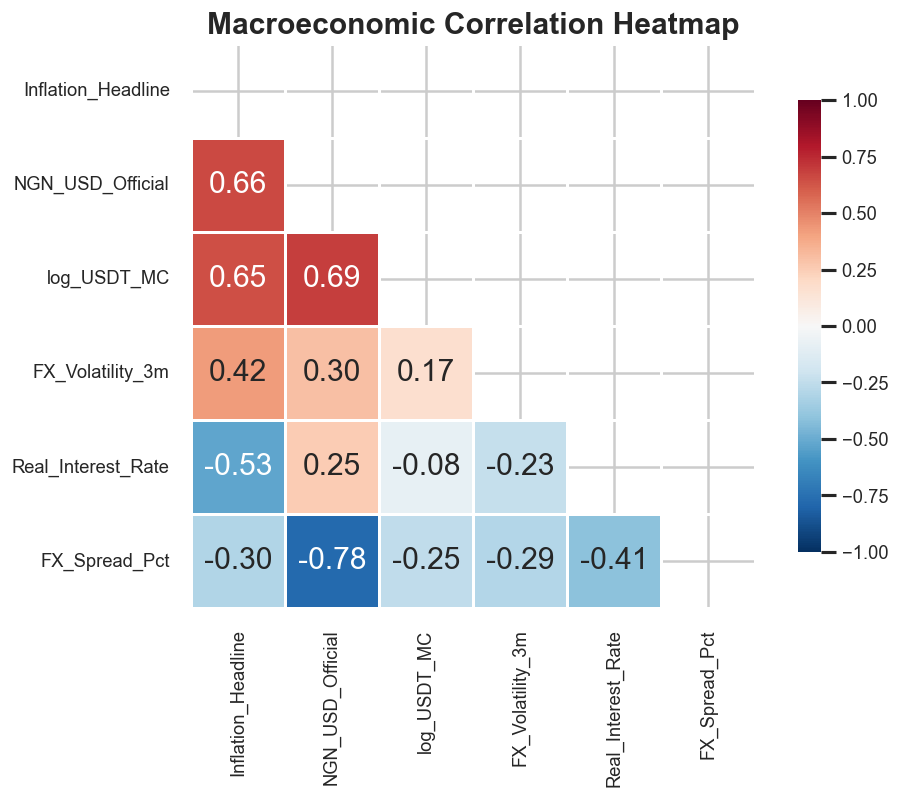


Correlations with log_USDT_MC (sorted):
NGN_USD_Official      0.6899
Inflation_Headline    0.6463
FX_Volatility_3m      0.1685
Real_Interest_Rate   -0.0809
FX_Spread_Pct        -0.2524
Name: log_USDT_MC, dtype: float64


In [12]:
key_cols = [
    "Inflation_Headline",
    "NGN_USD_Official",
    "log_USDT_MC",
    "FX_Volatility_3m",
    "Real_Interest_Rate",
    "FX_Spread_Pct",
]

corr_matrix = df[key_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.8,
    square=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Macroeconomic Correlation Heatmap")
plt.tight_layout()
plt.show()

# Print top correlations with the target proxy
print("\nCorrelations with log_USDT_MC (sorted):")
print(corr_matrix["log_USDT_MC"].drop("log_USDT_MC").sort_values(ascending=False).round(4))

---
## 8. Inflation vs Stablecoin Adoption <a id='8'></a>

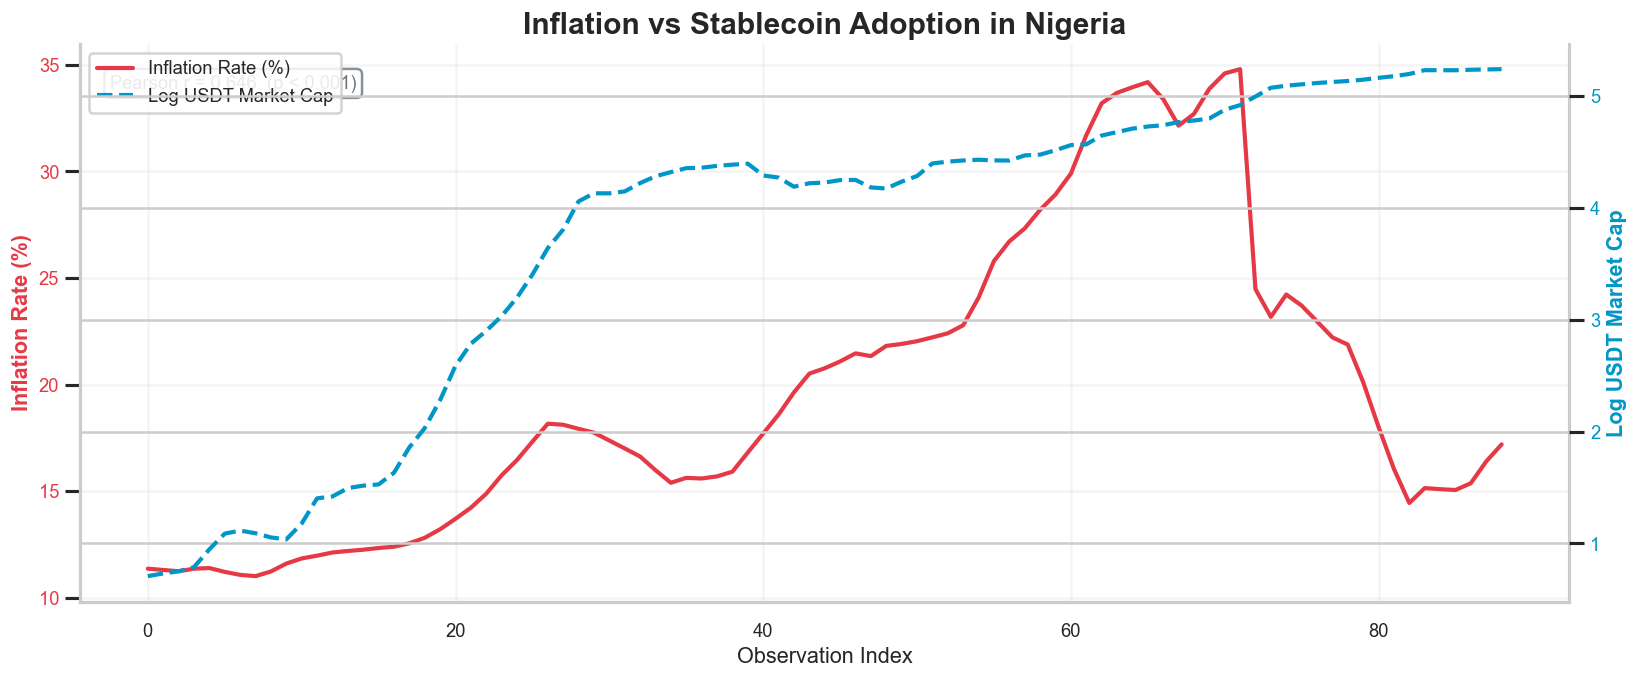

In [13]:
# ── FIX: merged two near-identical dual-axis charts into one clean plot
# Added: combined legend (twinx legends don't merge automatically),
# Pearson r annotation, and despine on both axes.

fig, ax1 = plt.subplots(figsize=(14, 6))

# Inflation (left axis)
l1, = ax1.plot(df.index, df["Inflation_Headline"], color=RED, linewidth=2.5, label="Inflation Rate (%)")
ax1.set_ylabel("Inflation Rate (%)", color=RED, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=RED)
ax1.set_xlabel("Observation Index")
ax1.grid(alpha=0.2)

# Stablecoin adoption (right axis)
ax2 = ax1.twinx()
l2, = ax2.plot(df.index, df["log_USDT_MC"], color=TEAL, linewidth=2.5, linestyle="--", label="Log USDT Market Cap")
ax2.set_ylabel("Log USDT Market Cap", color=TEAL, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=TEAL)

# Combined legend
ax1.legend(handles=[l1, l2], loc="upper left", framealpha=0.85)

# Pearson correlation annotation
r, p = stats.pearsonr(df["Inflation_Headline"].dropna(), df["log_USDT_MC"].dropna())
ax1.annotate(
    f"Pearson r = {r:.3f}  (p {'< 0.001' if p < 0.001 else f'= {p:.3f}'})",
    xy=(0.02, 0.92), xycoords="axes fraction",
    fontsize=11, color=MUTED,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=MUTED, alpha=0.8),
)

ax1.set_title("Inflation vs Stablecoin Adoption in Nigeria")
sns.despine(ax=ax1, right=False)
plt.tight_layout()
plt.show()

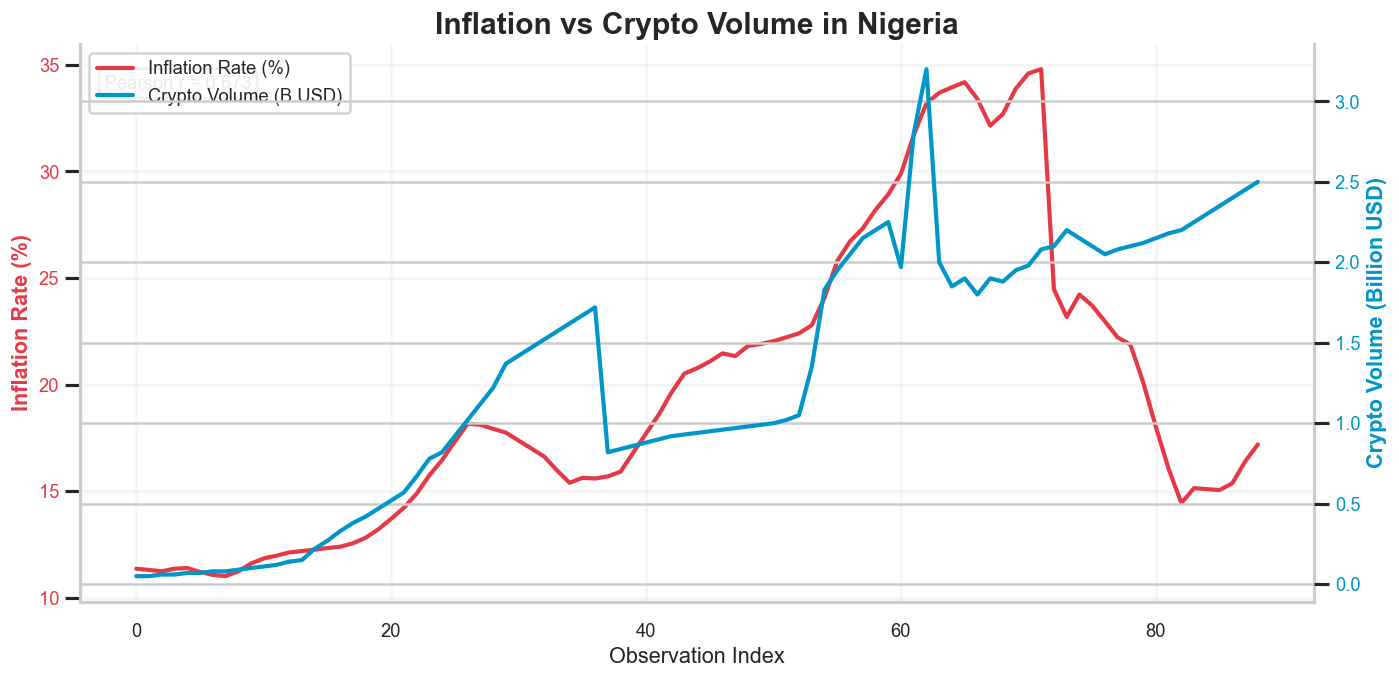

In [14]:
# ── Crypto Volume vs Inflation ─────────────────────────────────────
# FIX: this chart previously had no legend and no correlation stat.

fig, ax1 = plt.subplots(figsize=(12, 6))

l1, = ax1.plot(df.index, df["Inflation_Headline"], color=RED, linewidth=2.5, label="Inflation Rate (%)")
ax1.set_ylabel("Inflation Rate (%)", color=RED, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=RED)
ax1.set_xlabel("Observation Index")
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()
l2, = ax2.plot(df.index, df["SC_Nigeria_Vol_B_USD"], color=TEAL, linewidth=2.5, label="Crypto Volume (B USD)")
ax2.set_ylabel("Crypto Volume (Billion USD)", color=TEAL, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=TEAL)

ax1.legend(handles=[l1, l2], loc="upper left", framealpha=0.85)

r2, p2 = stats.pearsonr(
    df[["Inflation_Headline", "SC_Nigeria_Vol_B_USD"]].dropna()["Inflation_Headline"],
    df[["Inflation_Headline", "SC_Nigeria_Vol_B_USD"]].dropna()["SC_Nigeria_Vol_B_USD"]
)
ax1.annotate(
    f"Pearson r = {r2:.3f}",
    xy=(0.02, 0.92), xycoords="axes fraction",
    fontsize=11, color = MUTED,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=MUTED, alpha=0.8),
)

ax1.set_title("Inflation vs Crypto Volume in Nigeria")
sns.despine(ax=ax1, right=False)
plt.tight_layout()
plt.show()

---
## 9. Exchange Rate & FX Volatility <a id='9'></a>

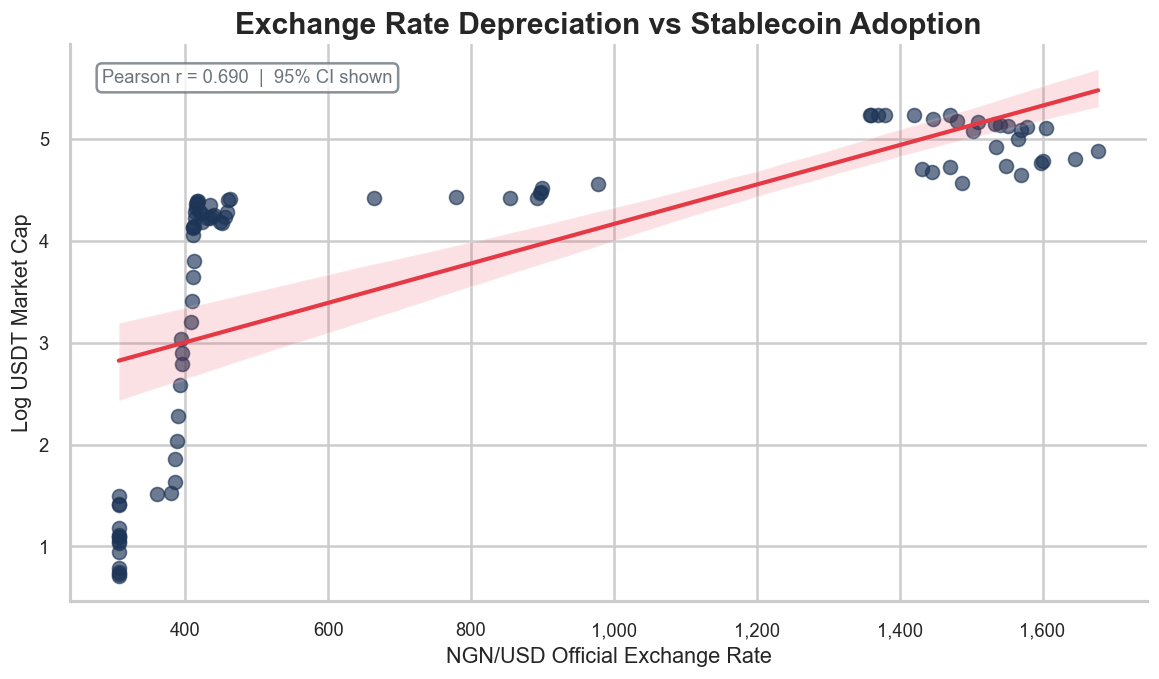

In [15]:
# ── Exchange Rate Depreciation vs Stablecoin Adoption ─────────────
# FIX: added confidence interval label, Pearson r annotation,
# and readable axis tick formatting.

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    x=df["NGN_USD_Official"],
    y=df["log_USDT_MC"],
    scatter_kws={"s": 70, "alpha": 0.65, "color": NAVY},
    line_kws={"linewidth": 2.5, "color": RED},
    ci=95,
    ax=ax,
)

r_fx, p_fx = stats.pearsonr(
    df[["NGN_USD_Official", "log_USDT_MC"]].dropna()["NGN_USD_Official"],
    df[["NGN_USD_Official", "log_USDT_MC"]].dropna()["log_USDT_MC"]
)
ax.annotate(
    f"Pearson r = {r_fx:.3f}  |  95% CI shown",
    xy=(0.03, 0.93), xycoords="axes fraction",
    fontsize=11, color=MUTED,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=MUTED, alpha=0.8),
)

ax.set_title("Exchange Rate Depreciation vs Stablecoin Adoption")
ax.set_xlabel("NGN/USD Official Exchange Rate")
ax.set_ylabel("Log USDT Market Cap")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

sns.despine()
plt.tight_layout()
plt.show()

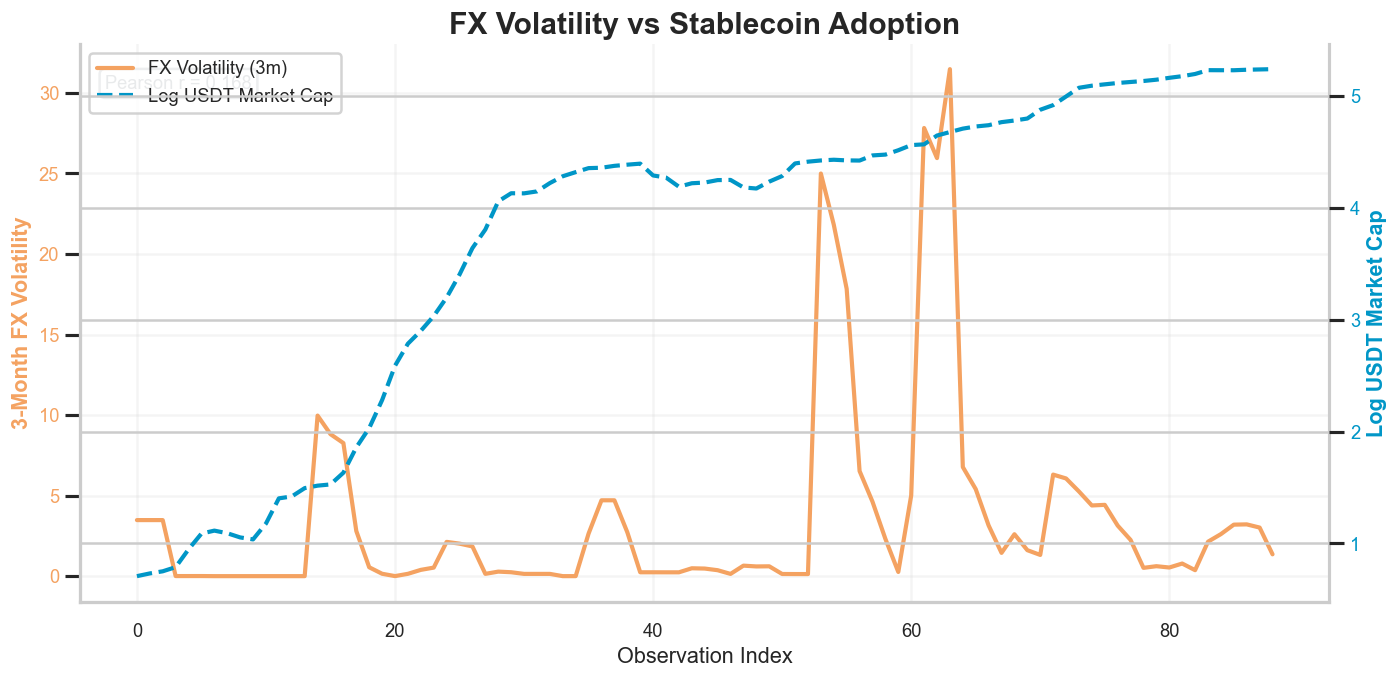

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))

l1, = ax1.plot(df.index, df["FX_Volatility_3m"], color=AMBER, linewidth=2.5, label="FX Volatility (3m)")
ax1.set_ylabel("3-Month FX Volatility", color=AMBER, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=AMBER)
ax1.set_xlabel("Observation Index")
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()
l2, = ax2.plot(df.index, df["log_USDT_MC"], color=TEAL, linewidth=2.5, linestyle="--", label="Log USDT Market Cap")
ax2.set_ylabel("Log USDT Market Cap", color=TEAL, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=TEAL)

ax1.legend(handles=[l1, l2], loc="upper left", framealpha=0.85)

r_vol, _ = stats.pearsonr(
    df[["FX_Volatility_3m", "log_USDT_MC"]].dropna()["FX_Volatility_3m"],
    df[["FX_Volatility_3m", "log_USDT_MC"]].dropna()["log_USDT_MC"]
)
ax1.annotate(
    f"Pearson r = {r_vol:.3f}",
    xy=(0.02, 0.92), xycoords="axes fraction",
    fontsize=11, color=MUTED,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=MUTED, alpha=0.8),
)

ax1.set_title("FX Volatility vs Stablecoin Adoption")
sns.despine(ax=ax1, right=False)
plt.tight_layout()
plt.show()

---
## 10. Event Study: Naira Float <a id='10'></a>

In [17]:
before = df[df["D_Naira_Float"] == 0]["log_USDT_MC"].dropna()
after  = df[df["D_Naira_Float"] == 1]["log_USDT_MC"].dropna()

t_stat, t_p = stats.ttest_ind(before, after)

print(f"Before Float  — Mean: {before.mean():.4f}  |  N: {len(before)}")
print(f"After Float   — Mean: {after.mean():.4f}  |  N: {len(after)}")
print(f"Difference    — {after.mean() - before.mean():+.4f}")
print(f"Independent t-test: t = {t_stat:.3f},  p = {t_p:.4f}")
if t_p < 0.05:
    print("Difference is statistically significant at the 5% level.")
else:
    print("Difference is NOT statistically significant at the 5% level.")

Before Float  — Mean: 2.9737  |  N: 53
After Float   — Mean: 4.8810  |  N: 36
Difference    — +1.9073
Independent t-test: t = -7.951,  p = 0.0000
Difference is statistically significant at the 5% level.


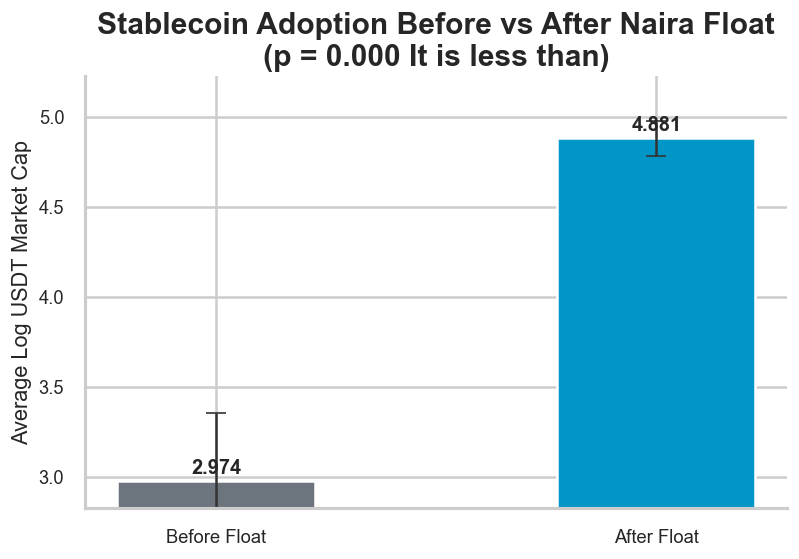

In [18]:
event_means = pd.DataFrame({
    "Period":  ["Before Float", "After Float"],
    "Adoption": [before.mean(), after.mean()],
    "SE":       [before.sem(),  after.sem()],
})

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    event_means["Period"],
    event_means["Adoption"],
    color=[MUTED, TEAL],
    width=0.45,
    yerr=event_means["SE"] * 1.96,   # 95% CI error bars
    capsize=6,
    error_kw={"elinewidth": 1.5, "ecolor": "#333"},
)

# Value labels on bars
for bar, val in zip(bars, event_means["Adoption"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

sig_label = f"p = {t_p:.3f} {'It is less than' if t_p < 0.05 else 'It is greater than'}"
ax.set_title(f"Stablecoin Adoption Before vs After Naira Float\n({sig_label})")
ax.set_ylabel("Average Log USDT Market Cap")
ax.set_ylim(bottom=event_means["Adoption"].min() * 0.95)

sns.despine()
plt.tight_layout()
plt.show()

---
## 11. Feature Selection & Modelling Setup <a id='11'></a>

In [19]:

FEATURES = [
    "Inflation_Headline",
    "FX_Return_Official",
    "Real_Interest_Rate",
    "FX_Spread_Pct",
]
TARGET = "SC_Nigeria_Vol_B_USD"

data = df[FEATURES + [TARGET]].dropna()
X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Scale for linear model only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Feature matrix shape: {X.shape}")

Train size: 71  |  Test size: 18
Feature matrix shape: (89, 4)


---
## 12. Linear Regression <a id='12'></a>

In [20]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# 5-fold cross-validation on full scaled data
X_scaled_full = scaler.fit_transform(X)
cv_scores_lr = cross_val_score(LinearRegression(), X_scaled_full, y, cv=5, scoring="r2")

print("─" * 40)
print("  LINEAR REGRESSION — PERFORMANCE")
print("─" * 40)
print(f"  R²   (test set):     {r2_lr:.4f}")
print(f"  MAE  (test set):     {mae_lr:.4f}")
print(f"  RMSE (test set):     {rmse_lr:.4f}")
print(f"  R²   (5-fold CV):    {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print("─" * 40)

────────────────────────────────────────
  LINEAR REGRESSION — PERFORMANCE
────────────────────────────────────────
  R²   (test set):     0.6586
  MAE  (test set):     0.3886
  RMSE (test set):     0.4746
  R²   (5-fold CV):    -105.7519 ± 150.2962
────────────────────────────────────────


           Feature  Std. Coefficient
     FX_Spread_Pct         -0.013392
FX_Return_Official         -0.013267
Real_Interest_Rate          0.426894
Inflation_Headline          0.758165


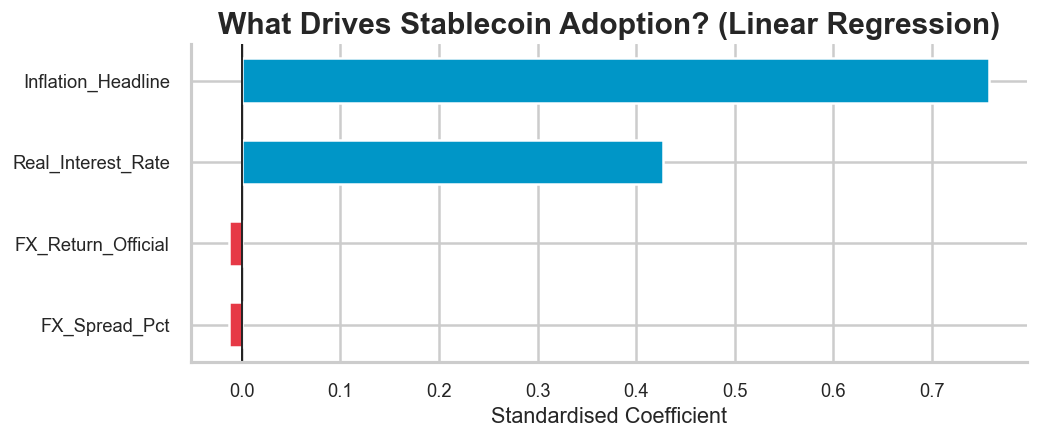

In [21]:
# ── FIX: show standardised coefficients (comparable across features)
# and add a zero reference line with a label.

coef_df = pd.DataFrame({
    "Feature":             FEATURES,
    "Std. Coefficient":    lr.coef_,
}).sort_values("Std. Coefficient")

print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = [RED if v < 0 else TEAL for v in coef_df["Std. Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Std. Coefficient"], color=colors, edgecolor="white", height=0.55)
ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlabel("Standardised Coefficient")
ax.set_title("What Drives Stablecoin Adoption? (Linear Regression)")
sns.despine()
plt.tight_layout()
plt.show()

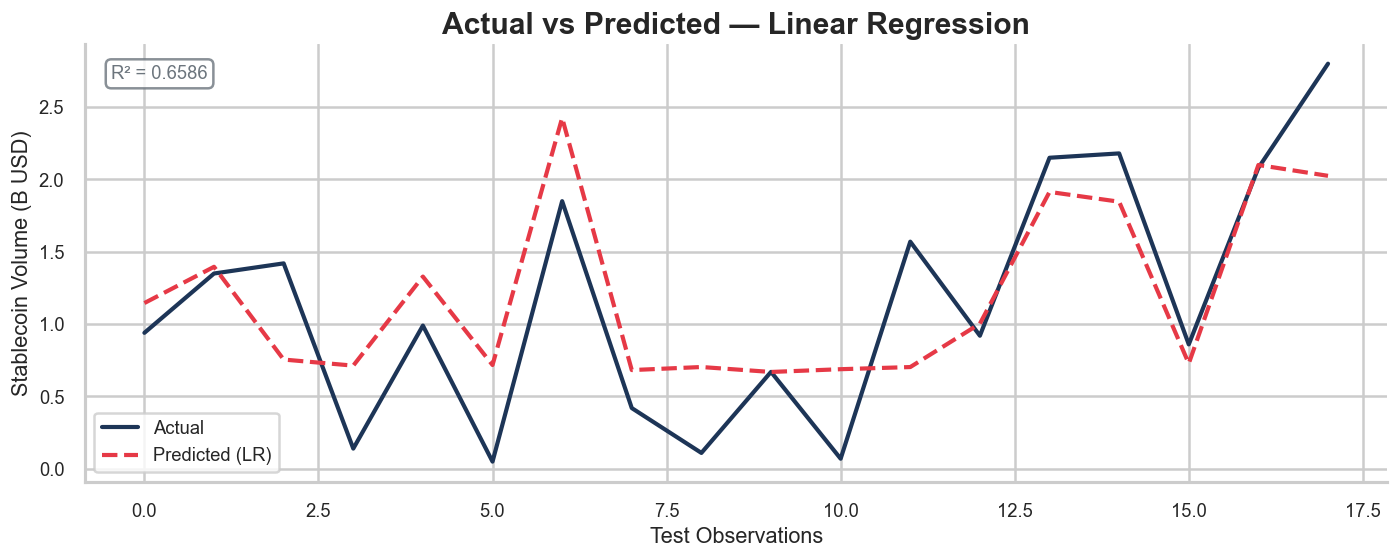

In [22]:
sorted_idx = y_test.reset_index(drop=True).sort_index()
actual_sorted = y_test.values

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual_sorted, color=NAVY,  linewidth=2.5, label="Actual")
ax.plot(y_pred_lr,     color=RED,   linewidth=2.5, linestyle="--", label="Predicted (LR)")
ax.set_title("Actual vs Predicted — Linear Regression")
ax.set_xlabel("Test Observations")
ax.set_ylabel("Stablecoin Volume (B USD)")
ax.legend()
ax.annotate(f"R² = {r2_lr:.4f}", xy=(0.02, 0.92), xycoords="axes fraction",
            fontsize=11, color=MUTED,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=MUTED, alpha=0.8))
sns.despine()
plt.tight_layout()
plt.show()

---
## 13. Random Forest <a id='13'></a>

In [23]:
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)   # No scaling needed for tree models
y_pred_rf = rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

cv_scores_rf = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
                               X, y, cv=5, scoring="r2")

print("─" * 40)
print("  RANDOM FOREST — PERFORMANCE")
print("─" * 40)
print(f"  R²   (test set):     {r2_rf:.4f}")
print(f"  MAE  (test set):     {mae_rf:.4f}")
print(f"  RMSE (test set):     {rmse_rf:.4f}")
print(f"  R²   (5-fold CV):    {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print("─" * 40)

────────────────────────────────────────
  RANDOM FOREST — PERFORMANCE
────────────────────────────────────────
  R²   (test set):     0.8993
  MAE  (test set):     0.1662
  RMSE (test set):     0.2577
  R²   (5-fold CV):    -34.6526 ± 42.9728
────────────────────────────────────────


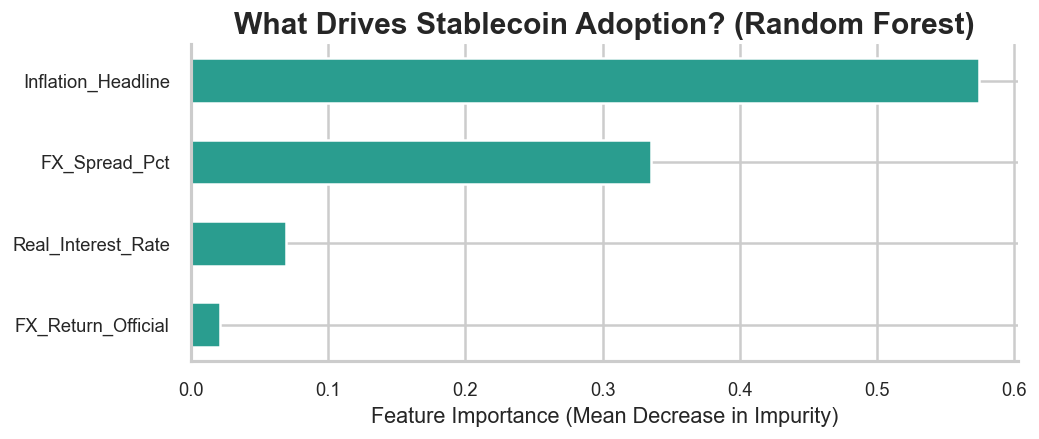

In [24]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(importances.index, importances.values, color=GREEN, edgecolor="white", height=0.55)
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("What Drives Stablecoin Adoption? (Random Forest)")
sns.despine()
plt.tight_layout()
plt.show()

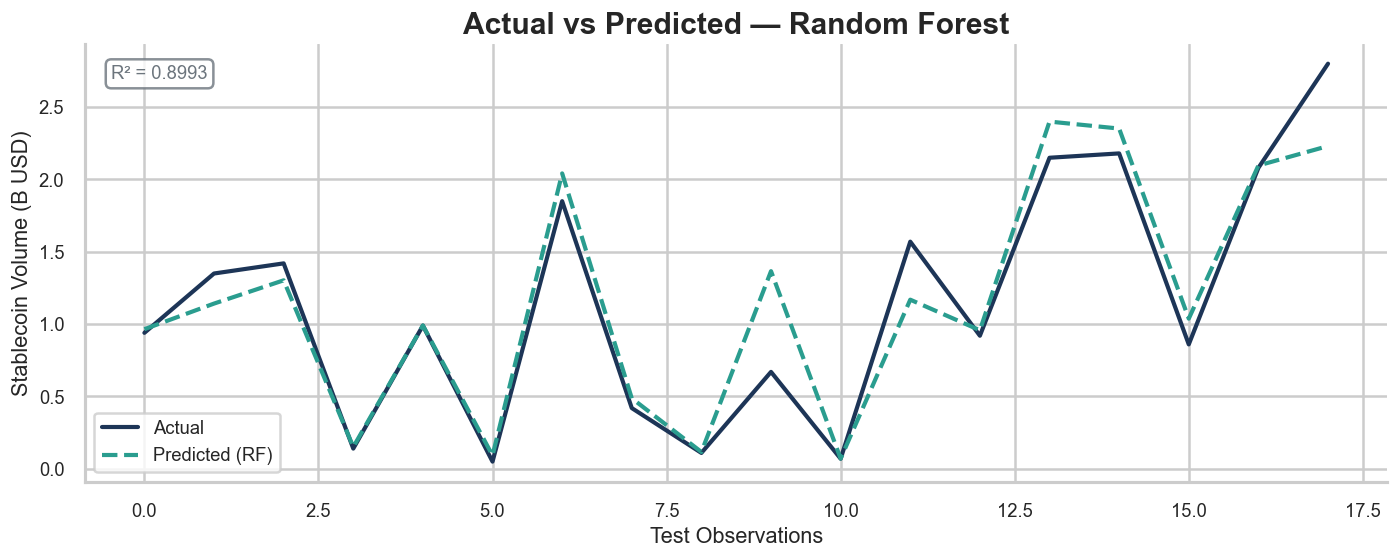

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual_sorted, color=NAVY,  linewidth=2.5, label="Actual")
ax.plot(y_pred_rf,     color=GREEN, linewidth=2.5, linestyle="--", label="Predicted (RF)")
ax.set_title("Actual vs Predicted — Random Forest")
ax.set_xlabel("Test Observations")
ax.set_ylabel("Stablecoin Volume (B USD)")
ax.legend()
ax.annotate(f"R² = {r2_rf:.4f}", xy=(0.02, 0.92), xycoords="axes fraction",
            fontsize=11, color = MUTED,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=MUTED, alpha=0.8))
sns.despine()
plt.tight_layout()
plt.show()

---
## 14. Model Comparison <a id='14'></a>

In [26]:
comparison = pd.DataFrame({
    "Model":        ["Linear Regression", "Random Forest"],
    "R² (test)": [round(r2_lr, 4),  round(r2_rf, 4)],
    "MAE (test)": [round(mae_lr, 4), round(mae_rf, 4)],
    "RMSE (test)":[round(rmse_lr,4), round(rmse_rf,4)],
    "CV R² (mean)":[round(cv_scores_lr.mean(), 4), round(cv_scores_rf.mean(), 4)],
    "CV R² (std)": [round(cv_scores_lr.std(),  4), round(cv_scores_rf.std(),  4)],
})
print(comparison.to_string(index=False))

            Model  R² (test)  MAE (test)  RMSE (test)  CV R² (mean)  CV R² (std)
Linear Regression     0.6586      0.3886       0.4746     -105.7519     150.2962
    Random Forest     0.8993      0.1662       0.2577      -34.6526      42.9728


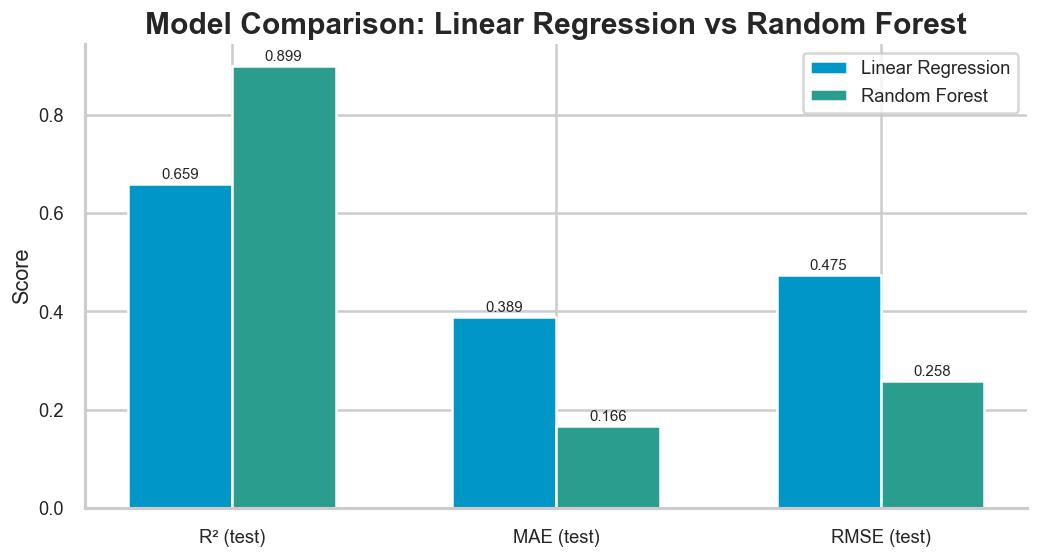


 Interpretation:
  Random Forest outperforms Linear Regression on R² (0.8993 vs 0.6586).
  The gap suggests non-linear relationships in the data.


In [27]:
metrics = ["R² (test)", "MAE (test)", "RMSE (test)"]
lr_vals = [r2_lr,  mae_lr,  rmse_lr]
rf_vals = [r2_rf,  mae_rf,  rmse_rf]

x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, lr_vals, width, label="Linear Regression", color=TEAL,  edgecolor="white")
b2 = ax.bar(x + width/2, rf_vals, width, label="Random Forest",     color=GREEN, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title("Model Comparison: Linear Regression vs Random Forest")
ax.set_ylabel("Score")
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

print("\n Interpretation:")
print(f"  Random Forest {'outperforms' if r2_rf > r2_lr else 'underperforms'} Linear Regression on R² ({r2_rf:.4f} vs {r2_lr:.4f}).")
print(f"  The gap suggests {'non-linear relationships in the data.' if r2_rf > r2_lr else 'the relationship is approximately linear.'}")